In [6]:
import sys
sys.path.insert(0, '..')
import random
import pandas as pd 
from importlib import reload
import MLPModel, LinearModel, Model_Training, DataDownload
import numpy as np

reload(MLPModel)
reload(LinearModel)
reload(Model_Training)

import torch

In [ ]:


ticker = "AAPL"
start = '2019-01-01'    # start date
end  = '2026-01-01'     # end date
interval = '1d'         # interval
train_ratio = 0.75
no_epoches = 100_000
lr = 0.001
tx_fees_bpts = 0
threshold = 0.001

weight_decay = 5e-3

max_lags = 24

modelMLP = MLPModel.MLP # multiplayer perception 

modelLinear = LinearModel.LinearModel # Linear Model equivalent to AR tine series



In [3]:
def evaluate_seeds(
    model_factory,
    model_name,
    seeds,
):
    results = []

    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        trained = Model_Training.model_training(
            model=model_factory(max_lags),
            tick=ticker,
            start=start,
            end=end,
            interval=interval,
            train_ratio=train_ratio,
            max_lags=max_lags,
            no_epochs=no_epoches,
            lr=lr,
            transaction_cost_bpts=tx_fees_bpts,
            weight_decay=weight_decay,
            trade_signal="threshold",
            threshold=threshold,
            verbose=False,
        )

        performance = trained.get_model_performance(
            trained.trade_results
        ).copy()

        performance["seed"] = seed
        performance["model"] = model_name
        results.append(performance)

    return pd.concat(
        results,
        ignore_index=True,
    )
    


In [4]:
def evaluate_seed_paths(
    model_factory,
    model_name,
    seeds,
    trainer_kwargs,
):
    metrics_list = []
    path_list = []
    max_lags = trainer_kwargs["max_lags"]
    for run, seed in enumerate(seeds):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        trained = Model_Training.model_training(
            model=model_factory(max_lags),
            **trainer_kwargs,
        )
        metrics = trained.get_model_performance(
            trained.trade_results
        ).copy()
        metrics["seed"] = seed
        metrics["model"] = model_name
        metrics_list.append(metrics)
        cumulative_return = np.expm1(
            trained.trade_results[
                "equity_log"
            ].to_numpy()
        ) * 100
        path = pd.Series(
            cumulative_return,
            index=trained.date_test,
            name=f"{model_name}_{run}_{seed}",
        )
        path_list.append(path)
    metrics_df = pd.concat(
        metrics_list,
        ignore_index=True,
    )
    paths_df = pd.concat(
        path_list,
        axis=1,
    )
    mean = paths_df.mean(axis=1)
    std = paths_df.std(axis=1)
    bands_df = pd.DataFrame(
        {
            "mean": mean,
            "std": std,
            "lower_1sigma": mean - std,
            "upper_1sigma": mean + std,
            "lower_2sigma": mean - 2 * std,
            "upper_2sigma": mean + 2 * std,
        }
    )
    return metrics_df, paths_df, bands_df

In [5]:
random_seeds = [random.randint(0,1_000_000) for _ in range(50)]  # pick 500 random seeds

# seed_MLP = evaluate_seeds(MLPModel.MLP,model_name = "MLP",seeds = random_seeds)
# seed_LIN = evaluate_seeds(LinearModel.LinearModel,model_name = "Linear",seeds = random_seeds) 
trainer_kwargs = {
    "tick": ticker,
    "start": start,
    "end": end,
    "interval": interval,
    "train_ratio": train_ratio,
    "max_lags": max_lags,
    "no_epochs": no_epoches,
    "lr": lr,
    "transaction_cost_bpts": tx_fees_bpts,
    "weight_decay": weight_decay,
    "trade_signal": "threshold",
    "threshold": threshold,
    "verbose": False,
}

mlp_metrics, mlp_paths, mlp_bands  = evaluate_seed_paths(MLPModel.MLP,model_name = "MLP",seeds = random_seeds, trainer_kwargs = trainer_kwargs)
lin_metrics, lin_paths, lin_bands = evaluate_seed_paths(LinearModel.LinearModel,model_name = "Linear",seeds = random_seeds, trainer_kwargs = trainer_kwargs) 



$AAPL: possibly delisted; no price data found  (1d 2019-01-01 -> 2026-01-01)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: possibly delisted; no price data found  (1d 2019-01-01 -> 2026-01-01)
/Users/stian/MPI/quant_stuff/repository/NeuralNetwork Pricing/networks/average_over_seeds/../Model_Training.py:114: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1861.)
  F_std = F_train.std(dim=0, keepdim=True).clamp_min(1e-8)
/Users/stian/MPI/quant_stuff/repository/NeuralNetwork Pricing/networks/average_over_seeds/../Model_Training.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/

KeyboardInterrupt: 

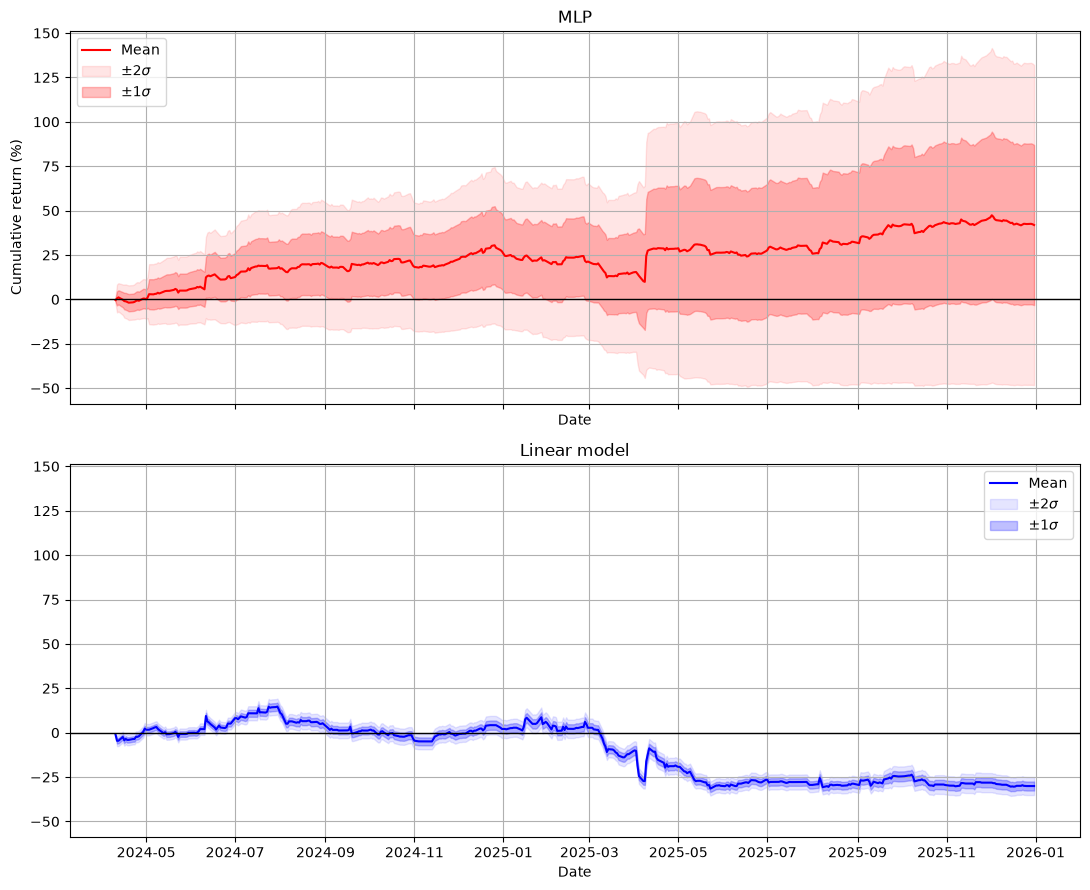

In [ ]:
from matplotlib import pyplot as plt

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(11, 9),
    sharex=True,
    sharey=True,
)

def plot_seed_bands(
    ax,
    bands,
    title,
    color,
):
    ax.plot(
        bands.index,
        bands["mean"],
        color=color,
        label="Mean",
    )

    ax.fill_between(
        bands.index,
        bands["lower_2sigma"],
        bands["upper_2sigma"],
        color=color,
        alpha=0.10,
        label=r"$\pm2\sigma$",
    )

    ax.fill_between(
        bands.index,
        bands["lower_1sigma"],
        bands["upper_1sigma"],
        color=color,
        alpha=0.25,
        label=r"$\pm1\sigma$",
    )

    ax.axhline(
        0,
        color="black",
        linewidth=1,
    )

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.grid(True)
    ax.legend()

plot_seed_bands(
    ax1,
    mlp_bands,
    title="MLP",
    color="red",
)

plot_seed_bands(
    ax2,
    lin_bands,
    title="Linear model",
    color="blue",
)

ax1.set_ylabel("Cumulative return (%)")

fig.tight_layout()
plt.show()

In [26]:
lags = [
    1,
    2,
    4,
    8,
    16,
    32,
]

lag_results = {
    "MLP": {},
    "Linear": {},
}

model_factories = {
    "MLP": MLPModel.MLP,
    "Linear": LinearModel.LinearModel,
}

for lag in lags:
    print(f"\nRunning lag {lag}...")

    lag_kwargs = trainer_kwargs.copy()
    lag_kwargs["max_lags"] = lag

    for model_name, model_factory in (
        model_factories.items()
    ):
        print(f"  {model_name}")

        metrics, paths, bands = (
            evaluate_seed_paths(
                model_factory=model_factory,
                model_name=model_name,
                seeds=random_seeds,
                trainer_kwargs=lag_kwargs,
            )
        )

        lag_results[model_name][lag] = {
            "metrics": metrics,
            "paths": paths,
            "bands": bands,
        }

max_drawdown_log                    drawdown_percentage            \
                  mean    median      std                mean    median   
model                                                                     
MLP          -0.538835 -0.513475  0.20457           -0.404695 -0.401586   

                 win_rate                     average_win  ... equity_peak  \
            std      mean    median       std        mean  ...         std   
model                                                      ...               
MLP    0.117559  0.490139  0.490741  0.038518     0.01101  ...     0.17287   

      return_std                     annualized_sharpe_stocks           \
            mean    median       std                     mean   median   
model                                                                    
MLP     0.017666  0.017731  0.000317                -0.414662 -0.48807   

                annualized_sharpe_crypto                      
            std                     mean    median       std  
model                                                         
MLP    0.791706                -0.499046 -0.587392  0.952818  

[1 rows x 42 columns]